# Spin-Orbit-Torque Demo


## Google Colab Link

The demo can be run on Google Colab without any local installation.
Use the following [link](https://colab.research.google.com/drive/1vfLhEUMGFCfJ-CB1QNKgZtLP6vkjf3hw#scrollTo=54df1504) to try out.

## Install magnum.np and download reference data if not available

In [1]:
!pip install -q magnumnp numpy==1.22.4

In [1]:
from os import path
if not path.isdir("ref"):
    !mkdir ref
    !wget -P ref https://gitlab.com/nina_sturm/magnum.np/raw/main/demos/sot/ref/ref_magnumaf.dat
    !wget -P ref https://gitlab.com/nina_sturm/magnum.np/raw/main/demos/sot/ref/ref_magnumnp.dat

## Run Demo:

In [3]:
from magnumnp import *
import torch

Timer.enable()

# initialize mesh
eps = 1e-15
#n  = (2, 2, 2)
n  = (1, 1, 1)
dx = (1.0e-9, 1.0e-9, 1e-9)

mesh = Mesh(n, dx)
state = State(mesh)

# initialize polarization, p, and charge current amplitude
# thickness of thin film on which the SOT acts
p = state.Tensor((0, -1, 0))
je = 6.9e10
d = n[2] * dx[2]
Keff = 1200e3*constants.mu_0*0.4/2./constants.mu_0

state.material = {
    "Ms": 1200e3,
    "A": 15e-12,
    "Ku": Keff,
    "Ku_axis": [0, 0, 1],
    "gamma": 2.211e5,
    "alpha": 0.048,
    "eta_damp": -0.1, # both eta with opposite sign as magnum.af, same as magnum.pi
    "eta_field": 0.3,
    "p": p,
    "d": d,
    "je": je}

# initialize field terms
exchange = ExchangeField()
aniso = UniaxialAnisotropyField()
torque = SpinOrbitTorque()

# initialize magnetization that relaxes into s-state
state.m = state.Constant([0,0,1])

# relax without external field
llg = LLGSolver([exchange, aniso])
llg.relax(state)

# perform integration with external field
state.t = 0.
llg = LLGSolver([exchange, torque, aniso])
slogger = ScalarLogger("data/log.dat", ['t', 'm', torque.h])
flogger = FieldLogger("data/fields.pvd", ['m'])

while state.t < 1e-9-eps:
    slogger << state
    flogger << state
    llg.step(state, 1e-12)

Timer.print_report()

## Plot Results:

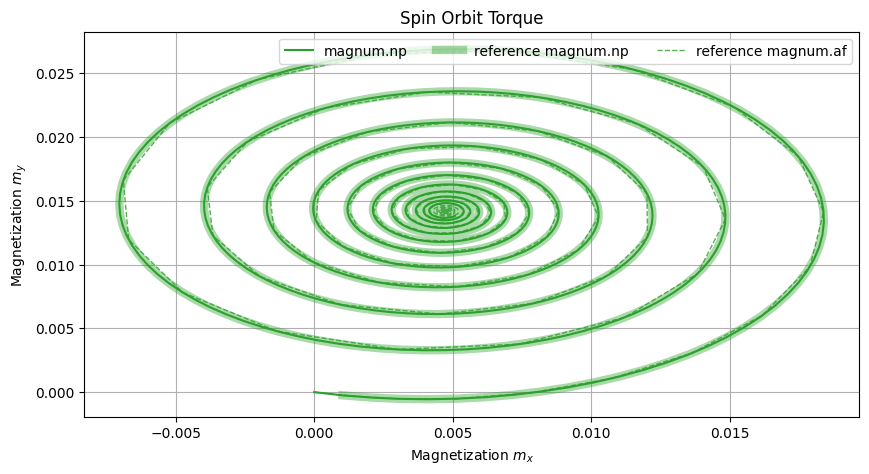

In [5]:
import matplotlib.pyplot as plt
import numpy as np

data = np.loadtxt("data/log.dat")
ref_np = np.loadtxt("ref/ref_magnumnp.dat")
ref_af = np.loadtxt("ref/ref_magnumaf.dat")

fig, ax = plt.subplots(figsize=(10,5))
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

ax.plot(data[:,1], data[:,2], '-', color = cycle[2], label = "magnum.np")
ax.plot(ref_np[:,1], ref_np[:,2], '-', color = cycle[2], linewidth = 6, alpha = 0.4, label = "reference magnum.np")
ax.plot(ref_af[:,1], ref_af[:,2], '--', color = cycle[2], linewidth = 1, alpha = 0.8, label = "reference magnum.af")

#ax.set_xlim([4.82,5.0])
#ax.set_ylim([0.99994,1.0])
ax.set_title("Spin Orbit Torque")
ax.set_xlabel("Magnetization $m_x$")
ax.set_ylabel("Magnetization $m_y$")
ax.legend(ncol=3)
ax.grid()
fig.savefig("data/results.png")